In [21]:
from GradientGang.Pipeline.DataLoader.DataLoader import DataModule

params = {
    'data_dir': "../dataset/PirateProcessed/",
    'train_file_name': "pirate_pain_train.csv",
    'train_file_name_labels': "pirate_pain_train_labels.csv",
    'test_file_name': "pirate_pain_test.csv",
    'batch_size': 32,
    'num_workers': 0,
    'val_split': 0.1,
    'shuffle': True,
}

dataLoader = DataModule(params=params)
dataLoader.setup(stage='fit')

trainLoader = dataLoader.train_dataloader()
valLoader = dataLoader.val_dataloader()

dataLoader.setup(stage='test')
testLoader = dataLoader.test_dataloader()

In [22]:
for batch in trainLoader:
    (time_series, global_features), labels = batch
    print("Train Batch - Time Series Shape:", time_series.shape)
    print("Train Batch - Global Features Shape:", global_features.shape)
    print("Train Batch - Labels Shape:", labels.shape)
    break

Train Batch - Time Series Shape: torch.Size([32, 34, 160])
Train Batch - Global Features Shape: torch.Size([32, 1])
Train Batch - Labels Shape: torch.Size([32])


In [23]:
# Check label values to understand the data
import torch
all_labels_check = []
for batch in trainLoader:
    (time_series, global_features), labels = batch
    all_labels_check.extend(labels.numpy())

print("Unique labels in training set:", set(all_labels_check))
print("Min label:", min(all_labels_check))
print("Max label:", max(all_labels_check))
print("Label counts:", {label: all_labels_check.count(label) for label in set(all_labels_check)})


Unique labels in training set: {np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}
Min label: -1
Max label: 2
Label counts: {np.int64(0): 467, np.int64(1): 82, np.int64(2): 46, np.int64(-1): 1324}


In [24]:
from GradientGang.Pipeline.Architectures.LightningAutoencoder import LightningAutoencoder
from torchsummary import summary

In [25]:
# Reload the modules to get the latest changes
import importlib
import GradientGang.Pipeline.Architectures.LightningAutoencoder
import GradientGang.Pipeline.Architectures.Decoder
import GradientGang.Pipeline.Architectures.Direct
importlib.reload(GradientGang.Pipeline.Architectures.Decoder)
importlib.reload(GradientGang.Pipeline.Architectures.LightningAutoencoder)
importlib.reload(GradientGang.Pipeline.Architectures.Direct)
from GradientGang.Pipeline.Architectures.Direct import Direct

print("✓ Modules reloaded successfully")


✓ Modules reloaded successfully


In [26]:
# Create an advanced autoencoder architecture
# Autoencoder: Encoder (GRU) -> Latent Space -> Decoder (GRU) + Classifier
architectureAutoencoder = {
    "LearningRate": 0.0005,
    "Patience": 10,
    "RegularizationWeight": 0.05,
    "ReconstructionLossWeight": 0.3,  # Balance between reconstruction and classification
    "ClassificationWeight": 0.7,
    
    # Encoder: Time series -> Latent representation
    "EncoderParams": {
        "activation_function": "GELU",
        "layer_type": [
            {
                "name": "GRU",
                "params": {
                    "input_size": 34,
                    "hidden_size": 256,  # Larger hidden size for better representation
                    "num_layers": 3,     # Deeper for more complex patterns
                    "bias": True,
                    "batch_first": True,
                    "dropout": 0.3,
                    "bidirectional": True  # Output: 512 (256*2)
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 512,
                    "out_features": 256,
                    "bias": True,
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 256,
                    "out_features": 128,  # Compressed latent representation
                    "bias": True,
                }
            }
        ]
    },
    
    # Global feature encoder (simple pass-through)
    "GlobalFFEncoderParams": {
        "activation_function": "LeakyReLU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 1,
                    "out_features": 1,
                    "bias": True,
                }
            },
        ]
    },
    
    # Global feature decoder (simple pass-through)
    "GlobalFFDecoderParams": {
        "activation_function": "LeakyReLU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 1,
                    "out_features": 1,
                    "bias": True,
                }
            },
        ]
    },
    
    # Decoder: Latent representation -> Reconstructed time series
    # NOTE: Decoder receives only the time series latent (128), not combined (129)
    "DecoderParams": {
        "activation_function": "GELU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 128,  # Only time series encoder output
                    "out_features": 256,
                    "bias": True,
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 256,
                    "out_features": 512,
                    "bias": True,
                }
            },
            {
                "name": "GRU",
                "params": {
                    "input_size": 512,
                    "hidden_size": 256,
                    "num_layers": 2,
                    "bias": True,
                    "batch_first": True,
                    "dropout": 0.2,
                    "bidirectional": False
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 256,
                    "out_features": 34,  # Reconstruct original time series features
                    "bias": True,
                }
            }
        ]
    },
    
    # Classification head: Combined latent -> Class predictions
    "FeedForwardParams": {
        "activation_function": "ReLU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 129,  # 128 (encoder) + 1 (global)
                    "out_features": 128,
                    "bias": True,
                }
            },
            {
                "name": "Dropout",
                "params": {
                    "p": 0.4
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 128,
                    "out_features": 64,
                    "bias": True,
                }
            },
            {
                "name": "Dropout",
                "params": {
                    "p": 0.3
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 64,
                    "out_features": 32,
                    "bias": True,
                }
            }
        ]
    },
    
    "OutputDim": 3,  # Number of classes
    "SequenceLength": 60,  # Time series length for decoder
    "UseJointLatent": True  # Use combined latent space for both reconstruction and classification
}

# Create autoencoder model
autoencoder_model = LightningAutoencoder(architectureAutoencoder)
print("✓ Autoencoder architecture created successfully")


✓ Autoencoder architecture created successfully


In [27]:
# Test the autoencoder architecture to verify it works correctly
import torch
with torch.no_grad():
    test_batch = next(iter(trainLoader))
    (test_time_series, test_global_features), test_labels = test_batch
    print("✓ Input time series shape:", test_time_series.shape)
    print("✓ Input global features shape:", test_global_features.shape)
    print("✓ Input labels shape:", test_labels.shape)
    
    # Autoencoder returns: (predictions, (reconstructed_time_series, reconstructed_global))
    output = autoencoder_model((test_time_series, test_global_features))
    predictions, (reconstructed_ts, reconstructed_global) = output
    
    print("\n✓ Output predictions shape:", predictions.shape)
    print("✓ Reconstructed time series shape:", reconstructed_ts.shape)
    print("✓ Reconstructed global features shape:", reconstructed_global.shape)
    
    print("\n" + "="*50)
    print("AUTOENCODER ARCHITECTURE VERIFICATION:")
    print("="*50)
    print(f"Predictions shape: {predictions.shape} -> Expected: ({test_time_series.shape[0]}, 3)")
    print(f"Reconstruction shape: {reconstructed_ts.shape} -> Expected: {test_time_series.shape}")
    print(f"Reconstructed global shape: {reconstructed_global.shape} -> Expected: {test_global_features.shape}")
    
    print(f"\n✅ Predictions match: {predictions.shape == (test_time_series.shape[0], 3)}")
    print(f"✅ Reconstruction match: {reconstructed_ts.shape == test_time_series.shape}")
    print(f"✅ Global reconstruction match: {reconstructed_global.shape == test_global_features.shape}")
    
    # Test prediction output
    print(f"\nPredicted classes: {predictions.argmax(dim=1)[:10]}")
    print(f"True labels: {test_labels[:10]}")
    
    # Check reconstruction quality
    mse_ts = torch.nn.functional.mse_loss(reconstructed_ts, test_time_series)
    mse_global = torch.nn.functional.mse_loss(reconstructed_global, test_global_features)
    print(f"\nTime Series Reconstruction MSE: {mse_ts.item():.6f}")
    print(f"Global Feature Reconstruction MSE: {mse_global.item():.6f}")


✓ Input time series shape: torch.Size([32, 34, 160])
✓ Input global features shape: torch.Size([32, 1])
✓ Input labels shape: torch.Size([32])

✓ Output predictions shape: torch.Size([32, 3])
✓ Reconstructed time series shape: torch.Size([32, 34, 160])
✓ Reconstructed global features shape: torch.Size([32, 1])

AUTOENCODER ARCHITECTURE VERIFICATION:
Predictions shape: torch.Size([32, 3]) -> Expected: (32, 3)
Reconstruction shape: torch.Size([32, 34, 160]) -> Expected: torch.Size([32, 34, 160])
Reconstructed global shape: torch.Size([32, 1]) -> Expected: torch.Size([32, 1])

✅ Predictions match: True
✅ Reconstruction match: True
✅ Global reconstruction match: True

Predicted classes: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
True labels: tensor([ 0,  0, -1, -1, -1, -1, -1,  0, -1, -1])

Time Series Reconstruction MSE: 0.653210
Global Feature Reconstruction MSE: 0.336906

✓ Output predictions shape: torch.Size([32, 3])
✓ Reconstructed time series shape: torch.Size([32, 34, 160])
✓ Reconstru

In [28]:
# Train the autoencoder with optimized settings
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping to prevent overfitting - monitor val_F1 instead of val_loss
early_stop_callback = EarlyStopping(
    monitor='val_F1',
    patience=15,
    mode='max',  # max because we want to maximize F1 score
    verbose=True
)

# Save best model checkpoint
checkpoint_callback = ModelCheckpoint(
    monitor='val_F1',
    mode='max',
    save_top_k=1,
    filename='autoencoder-best-{epoch:02d}-{val_F1:.3f}',
    verbose=True
)

# Create trainer with callbacks
trainer_autoencoder = Trainer(
    max_epochs=300,
    enable_progress_bar=True,
    log_every_n_steps=10,
    callbacks=[early_stop_callback, checkpoint_callback],
    gradient_clip_val=1.0,  # Prevent exploding gradients
)

print("Starting autoencoder training...")
trainer_autoencoder.fit(autoencoder_model, trainLoader, valLoader)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



  | Name             | Type              | Params | Mode 
---------------------------------------------------------------
0 | encoder          | Encoder           | 3.0 M  | train
1 | decoder          | Decoder           | 1.2 M  | train
2 | globalff_encoder | FeedForward       | 2      | train
3 | globalff_decoder | FeedForward       | 2      | train
4 | feedforward      | FeedForward       | 27.1 K | train
5 | val_f1           | MulticlassF1Score | 0      | train
---------------------------------------------------------------
4.2 M     Trainable params
0         Non-trainable params
4.2 M     Total params
16.659    Total estimated model params size (MB)
35        Modules in train mode
0         Modules in eval mode


Starting autoencoder training...
Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

c:\Users\teopa\Documents\ANN-Challenges\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


c:\Users\teopa\Documents\ANN-Challenges\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


...

Epoch 36: 100%|██████████| 60/60 [01:08<00:00,  0.87it/s, v_num=2, val_reconstruction_loss=0.532, val_F1=0.851]

Epoch 36, global step 2220: 'val_F1' was not in top 1


Epoch 37: 100%|██████████| 60/60 [01:03<00:00,  0.94it/s, v_num=2, val_reconstruction_loss=0.531, val_F1=0.859]

Monitored metric val_F1 did not improve in the last 15 records. Best score: 0.866. Signaling Trainer to stop.
Epoch 37, global step 2280: 'val_F1' was not in top 1
Epoch 37, global step 2280: 'val_F1' was not in top 1


Epoch 37: 100%|██████████| 60/60 [01:03<00:00,  0.94it/s, v_num=2, val_reconstruction_loss=0.531, val_F1=0.859]



In [29]:
# Evaluate autoencoder on validation set
from torchmetrics import F1Score
import torch

all_preds = []
all_labels = []
all_reconstructions = []
all_originals = []

for batch in valLoader:
    x, labels = batch
    with torch.no_grad():
        predictions, (reconstructed_ts, reconstructed_global) = autoencoder_model(x)
    
    all_preds.extend(predictions.argmax(dim=1).cpu().numpy())
    all_labels.extend(labels.cpu().numpy())
    all_reconstructions.append(reconstructed_ts.cpu())
    all_originals.append(x[0].cpu())  # time_series

# Classification metrics
f1_macro = F1Score(task="multiclass", num_classes=3, average='macro')
f1_weighted = F1Score(task="multiclass", num_classes=3, average='weighted')
f1_per_class = F1Score(task="multiclass", num_classes=3, average=None)

f1_macro_score = f1_macro(torch.tensor(all_preds), torch.tensor(all_labels))
f1_weighted_score = f1_weighted(torch.tensor(all_preds), torch.tensor(all_labels))
f1_per_class_scores = f1_per_class(torch.tensor(all_preds), torch.tensor(all_labels))

print("="*60)
print("AUTOENCODER EVALUATION RESULTS")
print("="*60)
print(f"\n📊 Classification Metrics:")
print(f"  - F1 Score (Macro):    {f1_macro_score:.4f}")
print(f"  - F1 Score (Weighted): {f1_weighted_score:.4f}")
print(f"  - F1 per class:")
print(f"      Class 0 (no_pain):   {f1_per_class_scores[0]:.4f}")
print(f"      Class 1 (low_pain):  {f1_per_class_scores[1]:.4f}")
print(f"      Class 2 (high_pain): {f1_per_class_scores[2]:.4f}")

# Reconstruction metrics
all_reconstructions = torch.cat(all_reconstructions, dim=0)
all_originals = torch.cat(all_originals, dim=0)
mse_loss = torch.nn.functional.mse_loss(all_reconstructions, all_originals)
mae_loss = torch.nn.functional.l1_loss(all_reconstructions, all_originals)

print(f"\n🔄 Reconstruction Metrics:")
print(f"  - MSE Loss: {mse_loss.item():.6f}")
print(f"  - MAE Loss: {mae_loss.item():.6f}")
print("="*60)


AUTOENCODER EVALUATION RESULTS

📊 Classification Metrics:
  - F1 Score (Macro):    0.7059
  - F1 Score (Weighted): 0.8250
  - F1 per class:
      Class 0 (no_pain):   0.9362
      Class 1 (low_pain):  0.7200
      Class 2 (high_pain): 0.4615

🔄 Reconstruction Metrics:
  - MSE Loss: 0.529353
  - MAE Loss: 0.344609


C:\Users\teopa\AppData\Local\Temp\ipykernel_12456\3503044930.py:33: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  axes[0].legend(*scatter1.legend_elements(), title="Classes",


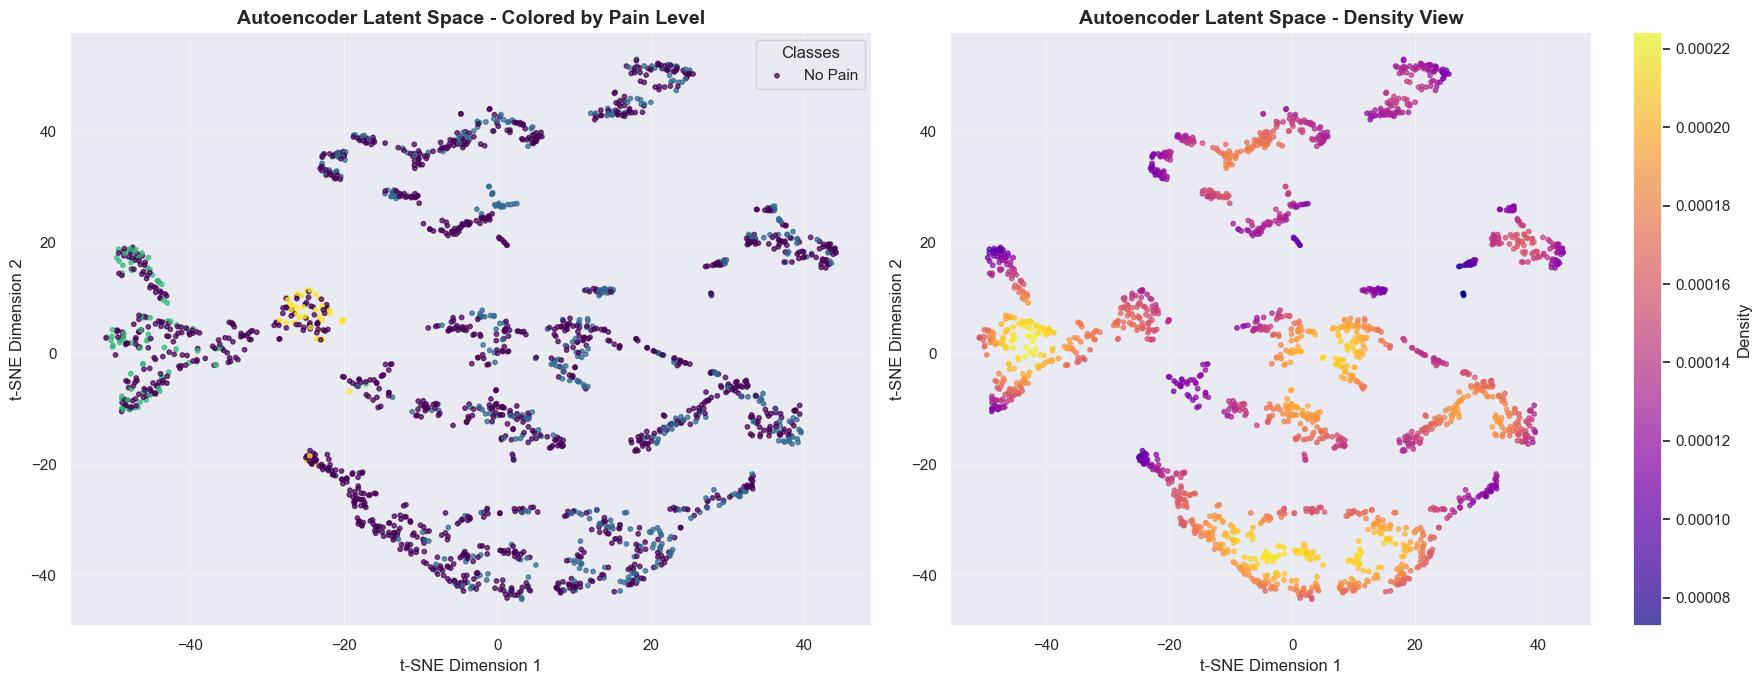

✓ Latent space dimension: 129
✓ Total samples visualized: 1919


In [30]:
# Visualize autoencoder latent space
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import torch
sns.set_theme()

embeddings = []
labels_list = []
for batch in trainLoader:
    (time_series, global_features), labels = batch
    with torch.no_grad():
        # Get the combined latent representation from the model
        encoded_ts = autoencoder_model.encoder(time_series)
        encoded_global = autoencoder_model.globalff_encoder(global_features)
        latent = torch.cat([encoded_ts, encoded_global], dim=1)
    embeddings.append(latent.cpu())
    labels_list.append(labels)

embeddings = torch.cat(embeddings, dim=0).numpy()
labels_list = torch.cat(labels_list, dim=0).numpy()

# Apply t-SNE for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Colored by class labels
scatter1 = axes[0].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                          c=labels_list, alpha=0.7, cmap='viridis', s=10)
axes[0].legend(*scatter1.legend_elements(), title="Classes", 
              labels=['No Pain', 'Low Pain', 'High Pain'])
axes[0].set_title('Autoencoder Latent Space - Colored by Pain Level', fontsize=14, fontweight='bold')
axes[0].set_xlabel('t-SNE Dimension 1', fontsize=12)
axes[0].set_ylabel('t-SNE Dimension 2', fontsize=12)
axes[0].grid(alpha=0.3)

# Plot 2: Density plot
from scipy.stats import gaussian_kde
xy = embeddings_2d.T
z = gaussian_kde(xy)(xy)
scatter2 = axes[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                          c=z, s=10, cmap='plasma', alpha=0.7)
plt.colorbar(scatter2, ax=axes[1], label='Density')
axes[1].set_title('Autoencoder Latent Space - Density View', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE Dimension 1', fontsize=12)
axes[1].set_ylabel('t-SNE Dimension 2', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Latent space dimension: {embeddings.shape[1]}")
print(f"✓ Total samples visualized: {embeddings.shape[0]}")


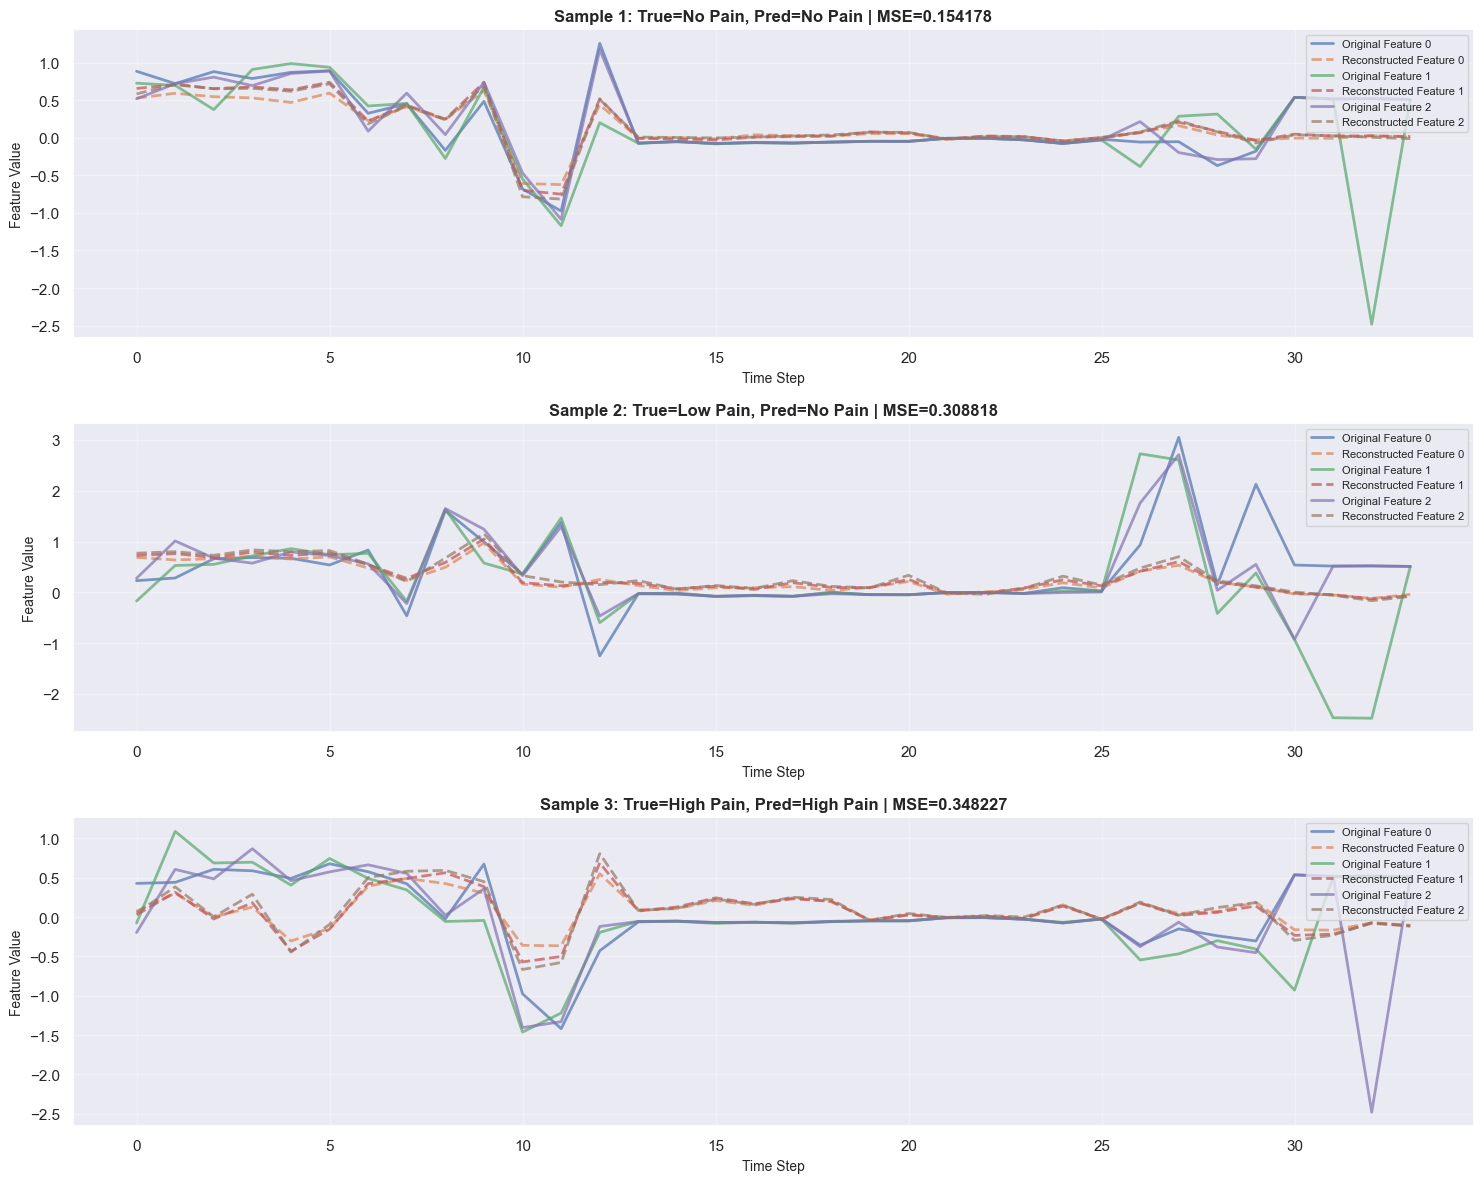

✓ Reconstruction visualization complete for 3 samples


In [31]:
# Visualize reconstruction quality
import matplotlib.pyplot as plt
import numpy as np

# Get a sample batch
sample_batch = next(iter(valLoader))
(sample_time_series, sample_global), sample_labels = sample_batch

with torch.no_grad():
    predictions, (reconstructed_ts, reconstructed_global) = autoencoder_model((sample_time_series, sample_global))

# Select 3 samples (one from each class if possible)
unique_labels = torch.unique(sample_labels)
sample_indices = []
for label in unique_labels[:3]:
    idx = (sample_labels == label).nonzero(as_tuple=True)[0][0].item()
    sample_indices.append(idx)

# Create visualization
fig, axes = plt.subplots(len(sample_indices), 1, figsize=(15, 4*len(sample_indices)))
if len(sample_indices) == 1:
    axes = [axes]

label_names = ['No Pain', 'Low Pain', 'High Pain']

for i, idx in enumerate(sample_indices):
    original = sample_time_series[idx].cpu().numpy()
    recon = reconstructed_ts[idx].cpu().numpy()
    true_label = sample_labels[idx].item()
    pred_label = predictions[idx].argmax().item()
    
    # Plot a subset of features (first 3 features for clarity)
    time_steps = range(original.shape[0])
    
    for feature_idx in range(min(3, original.shape[1])):
        axes[i].plot(time_steps, original[:, feature_idx], 
                    label=f'Original Feature {feature_idx}', alpha=0.7, linewidth=2)
        axes[i].plot(time_steps, recon[:, feature_idx], 
                    '--', label=f'Reconstructed Feature {feature_idx}', alpha=0.7, linewidth=2)
    
    mse = np.mean((original - recon) ** 2)
    axes[i].set_title(f'Sample {i+1}: True={label_names[true_label]}, Pred={label_names[pred_label]} | MSE={mse:.6f}', 
                     fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Time Step', fontsize=10)
    axes[i].set_ylabel('Feature Value', fontsize=10)
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Reconstruction visualization complete for {len(sample_indices)} samples")
